In [ ]:
# ── Colab Setup (run this cell first) ──────────────────────────────────────
!pip install -q pandas numpy scikit-learn matplotlib

# Notebook 2 — Trajectory Evaluation
### Evaluating AI Agents: From Component Checks to Adversarial Defense

---

## Learning Objectives

By the end of this notebook you will be able to:

1. Load and inspect pre-recorded agent traces.
2. Run reusable **trajectory assertions** across a trace suite.
3. Detect loops, duplicate tool calls, excessive steps, missing recovery, and cost/latency violations.
4. Produce a compact **per-trace pass/fail report** for regression monitoring.

> **Why trajectory evaluation?**  
> Two agents can produce the same final answer by very different paths.  
> One path may be efficient and recoverable. The other may be wasteful, stuck in loops, or silently failing.  
> Trajectory evaluation makes path quality measurable — not just output quality.

In [ ]:
# ── Setup and imports ──────────────────────────────────────────────────────
import sys, os

# Clone repo for Colab (skipped if already exists)
REPO_PATH = "/content/repo"
if not os.path.exists(REPO_PATH):
    !git clone https://github.com/MayssaHH/AI_Agent_Eval.git {REPO_PATH}
sys.path.insert(0, os.path.join(REPO_PATH, "evaluating-ai-agents-hands-on"))
os.chdir(os.path.join(REPO_PATH, "evaluating-ai-agents-hands-on", "notebooks"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams["figure.dpi"] = 110

from src.trace_utils import load_jsonl, trace_to_dataframe, summarize_trace
from src.metrics import (
    count_steps, total_latency, total_tokens,
    has_duplicate_consecutive_tool_calls, has_loop,
    has_recovery_after_failure, run_trajectory_assertions,
)

pd.set_option("display.max_colwidth", 55)
print("Setup complete.")

Setup complete.


In [2]:
# ── Load pre-recorded traces ───────────────────────────────────────────────
DATA_PATH = os.path.join("..", "data", "trajectories.jsonl")
traces = load_jsonl(DATA_PATH)

print(f"Loaded {len(traces)} agent traces.")
print("\nTrace IDs and profiles:")
for t in traces:
    print(f"  {t['trace_id']:10s}  profile={t.get('agent_profile','?'):25s}  steps={len(t['steps'])}")

Loaded 20 agent traces.

Trace IDs and profiles:
  tr_001      profile=clean                      steps=2
  tr_002      profile=clean                      steps=2
  tr_003      profile=excessive_steps            steps=6
  tr_004      profile=duplicate_calls            steps=3
  tr_005      profile=loop                       steps=4
  tr_006      profile=failure_with_recovery      steps=3
  tr_007      profile=failure_no_recovery        steps=1
  tr_008      profile=unnecessary_detour         steps=3
  tr_009      profile=premature_answer           steps=1
  tr_010      profile=high_latency               steps=2
  tr_011      profile=high_tokens                steps=3
  tr_012      profile=clean                      steps=2
  tr_013      profile=premature_answer           steps=1
  tr_014      profile=excessive_steps            steps=6
  tr_015      profile=failure_with_recovery      steps=3
  tr_016      profile=duplicate_calls            steps=3
  tr_017      profile=clean            

In [3]:
# ── Inspect one clean trace and one problematic trace ─────────────────────
def print_trace(trace, label=""):
    print(f"\n{'─'*60}")
    print(f"  {label}  |  trace_id={trace['trace_id']}  |  profile={trace.get('agent_profile')}")
    print(f"  task: {trace['task'][:65]}")
    print(f"{'─'*60}")
    for s in trace["steps"]:
        status_icon = "✓" if s["status"] == "success" else "✗"
        args_str = str(s.get("arguments", {}))[:45]
        print(f"  Step {s['step_id']} {status_icon}  {s.get('tool_name','—'):22s}  args={args_str}")
        print(f"         latency={s['latency_ms']}ms  tokens={s['tokens']}")
    print(f"  Final: {trace['final_answer'][:70]}")

clean   = next(t for t in traces if t.get("agent_profile") == "clean")
problem = next(t for t in traces if t.get("agent_profile") == "loop")

print_trace(clean,   label="CLEAN")
print_trace(problem, label="PROBLEMATIC (loop)")


────────────────────────────────────────────────────────────
  CLEAN  |  trace_id=tr_001  |  profile=clean
  task: Find recent papers on RAG evaluation and summarize the key findin
────────────────────────────────────────────────────────────
  Step 1 ✓  search_web              args={'query': 'RAG evaluation recent papers', 'da
         latency=700ms  tokens=120
  Step 2 ✓  summarize_evidence      args={'evidence': ['Paper 1: RAG benchmarks show 1
         latency=500ms  tokens=100
  Final: Recent RAG evaluation papers highlight two main themes: benchmark desi

────────────────────────────────────────────────────────────
  PROBLEMATIC (loop)  |  trace_id=tr_005  |  profile=loop
  task: Research the effects of learning rate scheduling on transformer t
────────────────────────────────────────────────────────────
  Step 1 ✓  search_web              args={'query': 'learning rate scheduling transform
         latency=500ms  tokens=100
  Step 2 ✓  search_web              args={'query': 'lear

In [4]:
# ── Build a summary dataframe across all traces ───────────────────────────
summaries = [summarize_trace(t) for t in traces]
df_summary = pd.DataFrame(summaries)

print("Trace-level summary:")
print(df_summary[["trace_id","n_steps","total_latency_ms","total_tokens","n_failures"]].to_string(index=False))

Trace-level summary:
trace_id  n_steps  total_latency_ms  total_tokens  n_failures
  tr_001        2              1200           220           0
  tr_002        2              1250           220           0
  tr_003        6              2500           500           0
  tr_004        3              1600           310           0
  tr_005        4              2000           400           0
  tr_006        3              1300           250           1
  tr_007        1               300            50           1
  tr_008        3              1700           330           0
  tr_009        1               200            40           0
  tr_010        2              6500           500           0
  tr_011        3              1500          2400           0
  tr_012        2              1350           240           0
  tr_013        1               150            30           0
  tr_014        6              2500           500           0
  tr_015        3              1650           295

In [5]:
# ── Run trajectory assertions over all traces ─────────────────────────────
#
# Assertion thresholds — tune these for your production SLAs.
MAX_STEPS      = 6      # more than 6 steps is considered bloated
MAX_LATENCY_MS = 5000   # 5 second budget per trace
MAX_TOKENS     = 1500   # token budget per trace

assertion_results = [
    run_trajectory_assertions(t, max_steps=MAX_STEPS,
                                 max_latency_ms=MAX_LATENCY_MS,
                                 max_tokens=MAX_TOKENS)
    for t in traces
]
df_assert = pd.DataFrame(assertion_results)

# Add profile column for readability
profile_map = {t["trace_id"]: t.get("agent_profile", "?") for t in traces}
df_assert.insert(1, "profile", df_assert["trace_id"].map(profile_map))

print(f"Assertions run with: max_steps={MAX_STEPS}, max_latency={MAX_LATENCY_MS}ms, max_tokens={MAX_TOKENS}")

Assertions run with: max_steps=6, max_latency=5000ms, max_tokens=1500


In [6]:
# ── Pass/fail table by trace ───────────────────────────────────────────────
assert_cols = [c for c in df_assert.columns if c.startswith("assert_")]

# Count passing assertions per trace
df_assert["pass_count"] = df_assert[assert_cols].sum(axis=1)
df_assert["total_assertions"] = len(assert_cols)
df_assert["all_pass"] = df_assert["pass_count"] == len(assert_cols)

display_cols = ["trace_id", "profile"] + assert_cols + ["pass_count", "all_pass"]

# Rename boolean columns to ✓/✗ for readability
def bool_to_symbol(val):
    return "✓" if val else "✗"

df_display = df_assert[display_cols].copy()
for col in assert_cols + ["all_pass"]:
    df_display[col] = df_display[col].map(bool_to_symbol)

print("Per-trace assertion results (✓ = pass, ✗ = fail):")
print(df_display.to_string(index=False))

Per-trace assertion results (✓ = pass, ✗ = fail):
trace_id               profile assert_max_steps assert_max_latency assert_max_tokens assert_no_dup_consecutive assert_no_loop assert_recovery_after_failure  pass_count all_pass
  tr_001                 clean                ✓                  ✓                 ✓                         ✓              ✓                             ✓           6        ✓
  tr_002                 clean                ✓                  ✓                 ✓                         ✓              ✓                             ✓           6        ✓
  tr_003       excessive_steps                ✓                  ✓                 ✓                         ✓              ✓                             ✓           6        ✓
  tr_004       duplicate_calls                ✓                  ✓                 ✓                         ✗              ✗                             ✓           4        ✗
  tr_005                  loop                ✓                  

Failure summary by assertion type:
             assertion  failures failure_rate
    no_dup_consecutive         4          20%
               no_loop         4          20%
recovery_after_failure         2          10%
           max_latency         1           5%
            max_tokens         1           5%
             max_steps         0           0%


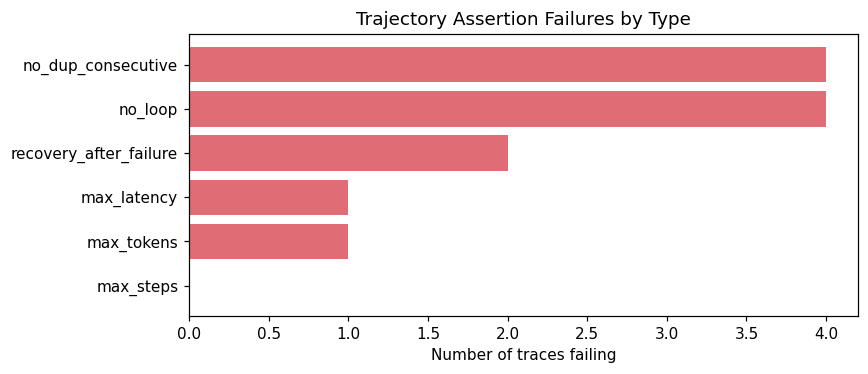

In [7]:
# ── Aggregate failure counts by assertion type ─────────────────────────────
failure_counts = {col: int((~df_assert[col]).sum()) for col in assert_cols}
df_failures = pd.DataFrame([
    {"assertion": k.replace("assert_", ""), "failures": v,
     "failure_rate": f"{v/len(traces):.0%}"}
    for k, v in failure_counts.items()
]).sort_values("failures", ascending=False)

print("Failure summary by assertion type:")
print(df_failures.to_string(index=False))

# Bar chart
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.barh(df_failures["assertion"], df_failures["failures"], color="#e06c75")
ax.set_xlabel("Number of traces failing")
ax.set_title("Trajectory Assertion Failures by Type")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join("..", "outputs", "nb02_assertion_failures.png"), bbox_inches="tight")
plt.show()

In [8]:
# ── Inspect one failed trace in detail ────────────────────────────────────
# Focus on the 'failure_no_recovery' case — agent hits an error and stops.

failed_trace = next(t for t in traces if t.get("agent_profile") == "failure_no_recovery")
result = run_trajectory_assertions(failed_trace, max_steps=MAX_STEPS,
                                                  max_latency_ms=MAX_LATENCY_MS,
                                                  max_tokens=MAX_TOKENS)

print_trace(failed_trace, label="FAILED TRACE (no recovery)")
print("\nAssertion results for this trace:")
for k, v in result.items():
    if k.startswith("assert_"):
        status = "✓ PASS" if v else "✗ FAIL"
        print(f"  {k.replace('assert_',''):35s} {status}")


────────────────────────────────────────────────────────────
  FAILED TRACE (no recovery)  |  trace_id=tr_007  |  profile=failure_no_recovery
  task: Retrieve the experimental results from doc_broken.
────────────────────────────────────────────────────────────
  Step 1 ✗  read_document           args={'doc_id': 'doc_broken'}
         latency=300ms  tokens=50
  Final: I encountered an error and could not complete the task.

Assertion results for this trace:
  max_steps                           ✓ PASS
  max_latency                         ✓ PASS
  max_tokens                          ✓ PASS
  no_dup_consecutive                  ✓ PASS
  no_loop                             ✓ PASS
  recovery_after_failure              ✗ FAIL


## Interpreting Trajectory Results

### Hard failure vs. warning

Not every assertion violation has the same severity. Use this decision guide:

| Violation | Recommended treatment |
|-----------|----------------------|
| **No recovery after failure** | Hard failure — agent abandons the task silently. Always block. |
| **Loop detected** | Hard failure — agent is stuck and will not self-resolve. Always block. |
| **Duplicate consecutive calls** | Hard failure — wastes compute and signals a planning bug. Block. |
| **Exceeded max steps** | Warning — may be an unusually complex task. Flag for review. |
| **Exceeded latency budget** | Warning — depends on user-facing SLA. Can be soft limit. |
| **Exceeded token budget** | Warning — monitor cost impact. Block only above critical threshold. |

**Key insight:** The agent in `tr_007` (failure_no_recovery) and `tr_020` (failure_no_recovery) both produce a final answer — they look fine if you only evaluate outputs. Trajectory evaluation reveals the silent failure that output scoring misses.

## Try It Yourself

**Extension exercise** — Tighten or relax the assertion thresholds and observe how the report changes:

```python
# Try stricter thresholds:
MAX_STEPS      = 3     # very strict
MAX_LATENCY_MS = 2000  # tight latency SLA
MAX_TOKENS     = 600   # low token budget

# Or more lenient:
MAX_STEPS      = 10
MAX_LATENCY_MS = 10000
MAX_TOKENS     = 5000

# Re-run the assertion block above and see which traces flip from pass to fail.
```

**Questions to explore:**
- Which profiles always fail regardless of thresholds? Which only fail under strict settings?
- Write a new assertion: `assert_has_citation` — checks that at least one step uses the `cite_sources` tool.
- How would you integrate these assertions into a CI/CD pipeline?